In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving spotify_user_behavior_realistic_50000_rows.csv to spotify_user_behavior_realistic_50000_rows.csv


In [3]:
df = pd.read_csv("spotify_user_behavior_realistic_50000_rows.csv")

In [ ]:
df.describe()

,user_id,age,months_inactive,inactive_3_months_flag,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,playlists_created,avg_skips_per_day
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,38.010280,1.533020,0.222460,3.644100,9.988986,8.002680,10.025920
std,14433.901067,12.984989,1.952082,0.415903,1.114424,3.968927,2.831571,3.165579
min,1.000000,16.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,12500.750000,27.000000,0.000000,0.000000,3.000000,7.280000,6.000000,8.000000
50%,25000.500000,38.000000,1.000000,0.000000,4.000000,9.980000,8.000000,10.000000
75%,37500.250000,49.000000,2.000000,0.000000,5.000000,12.680000,10.000000,12.000000
max,50000.000000,60.000000,18.000000,1.000000,5.000000,26.250000,23.000000,25.000000


In [4]:
df.drop(columns = ["user_id"], inplace = True)

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [6]:
import pandas as pd

def signup_date(X):
    X = X.copy()

    X["signup_date"] = pd.to_datetime(X["signup_date"])

    X["account_age_days"] = (pd.Timestamp.today() - X["signup_date"]).dt.days
    X["signup_month"] = X["signup_date"].dt.month
    X["signup_year"] = X["signup_date"].dt.year

    X = X.drop(columns=["signup_date"])

    return X

In [7]:
from sklearn.preprocessing import FunctionTransformer
date_transformer = FunctionTransformer(signup_date)

In [8]:
from sklearn.preprocessing import PowerTransformer

In [9]:
skewed_col = ["music_suggestion_rating_1_to_5","months_inactive", "inactive_3_months_flag","playlists_created", "avg_skips_per_day"]
categorical_col = ["country", "subscription_type", 'ad_interaction', "primary_device",
'ad_conversion_to_subscription', "favorite_genre", "most_liked_feature", "desired_future_feature"]
# numerical_col = ["age", "avg_listening_hours_per_week"]
numerical_col = [
"age",
"avg_listening_hours_per_week",
"account_age_days",
"signup_month",
"signup_year"
]

In [10]:
skewed_pipe = Pipeline([
("power", PowerTransformer(method = "yeo-johnson"))])

cat_pipe = Pipeline([
("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

num_pipe = Pipeline([
("scaler", StandardScaler())])

In [11]:
preprocessor = ColumnTransformer([
("skew", skewed_pipe, skewed_col),
("cat", cat_pipe, categorical_col),
("num", num_pipe, numerical_col)])

In [12]:
from sklearn.linear_model import LogisticRegression

In [13]:
X, y = df.drop(columns = ["subscription_status"]), df["subscription_status"]

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 13, stratify = y)

In [ ]:
base_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [ ]:
base_pipe = Pipeline([
("signup_date", date_transformer),
("preprocessing", preprocessor),
("logistic", base_model)
])

In [ ]:
base_pipe.fit(X_train, y_train)

Pipeline(steps=[('signup_date',
                 FunctionTransformer(func=<function signup_date at 0x7e0b2acf0ea0>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('skew',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['music_suggestion_rating_1_to_5',
                                                   'months_inactive',
                                                   'inactive_3_months_flag',
                                                   'playlists_created',
                                                   'avg_skips_per_day']),
                                                 ('cat',
                                                  Pipeline(steps=[('encode...
                                                   'ad_interaction',
                                                   'primary_device',
                                                   'ad_conversion_to_subscription',
                                                   'favorite_genre',
                                                   'most_liked_feature',
                                                   'desired_future_feature']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'avg_listening_hours_per_week',
                                                   'account_age_days',
                                                   'signup_month',
                                                   'signup_year'])])),
                ('logistic',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
y_pred = base_pipe.predict(X_test)

In [ ]:
y_pred_frame = pd.DataFrame(y_pred)

In [ ]:
y_pred_frame.value_counts()

,count
0,
Active,7797
Inactive,2203


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label='Active')}")
print(f"Recall : {recall_score(y_test, y_pred, pos_label='Active')}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='Active')}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Accuracy: 0.9375
Precision : 1.0
Recall : 0.9257895986701496
F1 Score : 0.9614649485171712
Classification Report:
              precision    recall  f1-score   support

      Active       1.00      0.93      0.96      8422
    Inactive       0.72      1.00      0.83      1578

    accuracy                           0.94     10000
   macro avg       0.86      0.96      0.90     10000
weighted avg       0.96      0.94      0.94     10000



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(f"confusion matrix :\n{cm}")

confusion matrix :
[[7797  625]
 [   0 1578]]


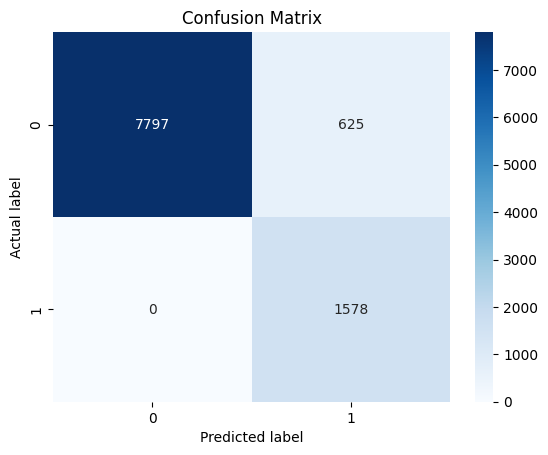

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
df.shape

(50000, 17)

In [ ]:
y_proba = base_pipe.predict_proba(X_test)[:, 1]

In [ ]:
base_pipe.classes_

array(['Active', 'Inactive'], dtype=object)

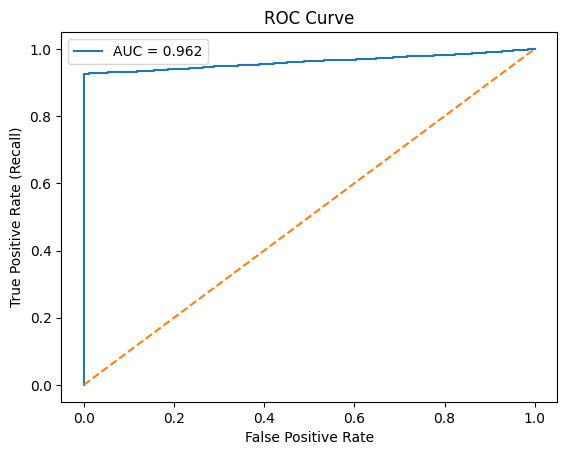

In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability for positive class ("Active")
y_proba = grid.predict_proba(X_test)[:, 0]

fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label="Active")
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()

plt.show()

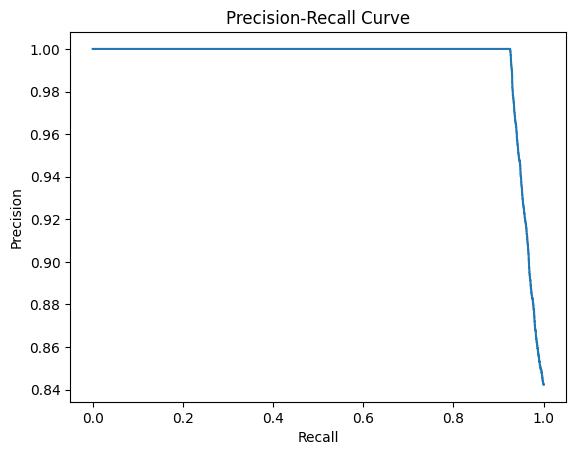

In [36]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_proba,
    pos_label="Active"
)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [ ]:
df.shape

(50000, 17)

In [ ]:
## Parameter Tuning Logistic Regression

In [16]:
logistic = LogisticRegression()

In [17]:
params = {
    "logistic__C": [0.01, 0.1, 1, 10],
    "logistic__penalty": ["l2"],
    "logistic__solver": ["lbfgs"]
}

In [18]:
pipe_model = Pipeline([
    ("signup_date", date_transformer),
    ("preprocessing", preprocessor),
    ("logistic", logistic)
])

In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
grid = GridSearchCV(pipe_model, params, cv=5, scoring="f1", n_jobs=-1, verbose=1)

In [21]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('signup_date',
                                        FunctionTransformer(func=<function signup_date at 0x781f40648ae0>)),
                                       ('preprocessing',
                                        ColumnTransformer(transformers=[('skew',
                                                                         Pipeline(steps=[('power',
                                                                                          PowerTransformer())]),
                                                                         ['music_suggestion_rating_1_to_5',
                                                                          'months_inactive',
                                                                          'inactive_3_months_flag',
                                                                          'playlists_created',
                                                                          'avg_skips_per_day']),
                                                                        ('c...
                                                                          'most_liked_feature',
                                                                          'desired_future_feature']),
                                                                        ('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'avg_listening_hours_per_week',
                                                                          'account_age_days',
                                                                          'signup_month',
                                                                          'signup_year'])])),
                                       ('logistic', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'logistic__C': [0.01, 0.1, 1, 10],
                         'logistic__penalty': ['l2'],
                         'logistic__solver': ['lbfgs']},
             scoring='f1', verbose=1)

In [22]:
y_pred = grid.predict(X_test)

In [23]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label='Active')}")
print(f"Recall : {recall_score(y_test, y_pred, pos_label='Active')}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='Active')}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Accuracy: 0.9375
Precision : 1.0
Recall : 0.9257895986701496
F1 Score : 0.9614649485171712
Classification Report:
              precision    recall  f1-score   support

      Active       1.00      0.93      0.96      8422
    Inactive       0.72      1.00      0.83      1578

    accuracy                           0.94     10000
   macro avg       0.86      0.96      0.90     10000
weighted avg       0.96      0.94      0.94     10000



In [24]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(f"confusion matrix :\n{cm}")

confusion matrix :
[[7797  625]
 [   0 1578]]


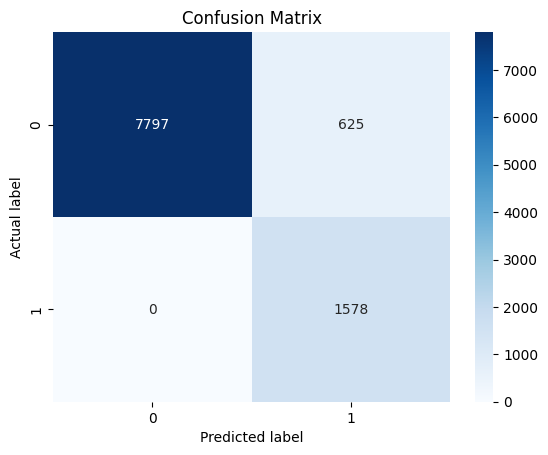

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix")
plt.show()

In [25]:
## Logistic Regression with smotenc

In [17]:
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

In [18]:
smote_nc = SMOTENC(
    categorical_features=categorical_col,
    random_state=42
)

In [ ]:
pipe_smotenc = ImbPipeline([
    ("signup_date", date_transformer),
    ("smote_nc", smote_nc),
    ("preprocessing", preprocessor),
    ("logistic", logistic)
])

In [ ]:
grid_pipe = GridSearchCV(pipe_smotenc, params, cv=5, scoring="f1", n_jobs=-1, verbose=1)

In [ ]:
grid_pipe.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('signup_date',
                                        FunctionTransformer(func=<function signup_date at 0x7e0b2acf0ea0>)),
                                       ('smote_nc',
                                        SMOTENC(categorical_features=['country',
                                                                      'subscription_type',
                                                                      'ad_interaction',
                                                                      'primary_device',
                                                                      'ad_conversion_to_subscription',
                                                                      'favorite_genre',
                                                                      'most_liked_feature',
                                                                      'desired_future_feature'],
                                                random_state=42)),
                                       ('prep...
                                                                          'most_liked_feature',
                                                                          'desired_future_feature']),
                                                                        ('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'avg_listening_hours_per_week',
                                                                          'account_age_days',
                                                                          'signup_month',
                                                                          'signup_year'])])),
                                       ('logistic', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'logistic__C': [0.01, 0.1, 1, 10],
                         'logistic__penalty': ['l2'],
                         'logistic__solver': ['lbfgs']},
             scoring='f1', verbose=1)

In [ ]:
y_pred = grid_pipe.predict(X_test)

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label='Active')}")
print(f"Recall : {recall_score(y_test, y_pred, pos_label='Active')}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='Active')}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Accuracy: 0.9375
Precision : 1.0
Recall : 0.9257895986701496
F1 Score : 0.9614649485171712
Classification Report:
              precision    recall  f1-score   support

      Active       1.00      0.93      0.96      8422
    Inactive       0.72      1.00      0.83      1578

    accuracy                           0.94     10000
   macro avg       0.86      0.96      0.90     10000
weighted avg       0.96      0.94      0.94     10000



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(f"confusion matrix :\n{cm}")

confusion matrix :
[[7797  625]
 [   0 1578]]


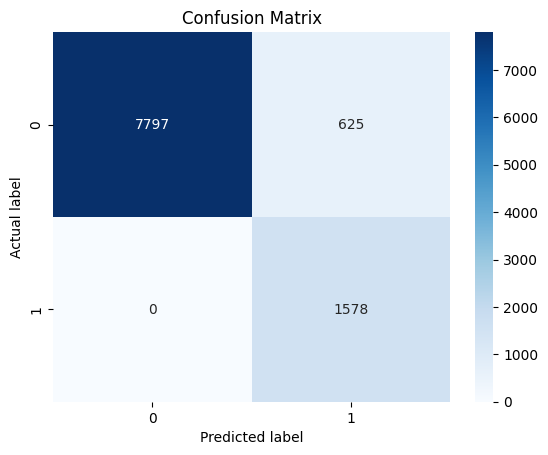

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
df.shape

(50000, 17)

In [ ]:
import joblib
joblib.dump(grid_pipe, "model.pkl")

['model.pkl']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
joblib.dump(grid_pipe, "/content/drive/MyDrive/model.pkl")

['/content/drive/MyDrive/model.pkl']

In [ ]:
# to load model
# model = joblib.load("/content/drive/MyDrive/model.pkl")

In [ ]:
import os
os.listdir()

['.config',
 'ROC-Curve.png',
 'confusion_matrix.png',
 'spotify_user_behavior_realistic_50000_rows.csv',
 'drive',
 'spotify_user_behavior_realistic_50000_rows (1).csv',
 'Precision-Recall-Curve.png',
 'model.pkl',
 'spotify_user_behavior_realistic_50000_rows (2).csv',
 'sample_data']

In [ ]:
df.head()

,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.head()

,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

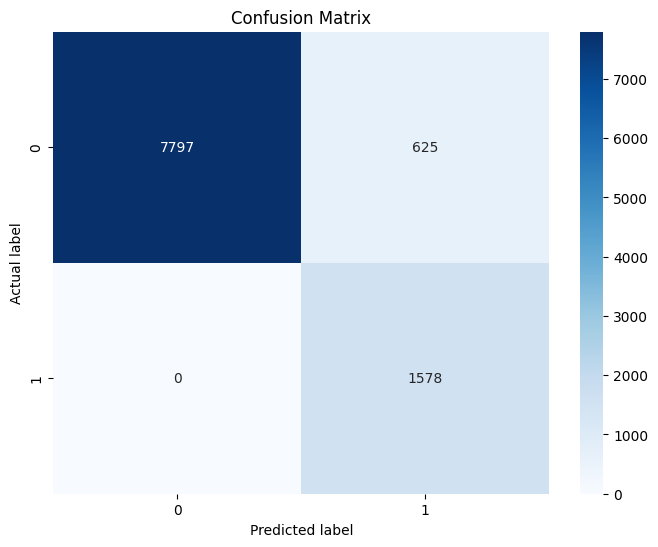

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix")

# Save the plot to a file
plot_filename = "confusion_matrix.png"
plt.savefig(plot_filename)

# Download the saved plot
from google.colab import files
files.download(plot_filename)

plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

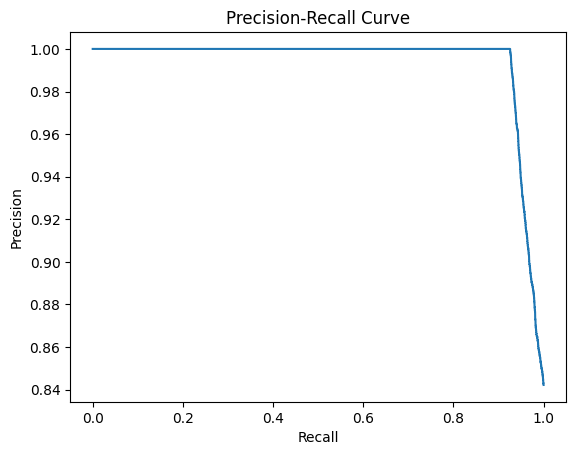

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_proba,
    pos_label="Active"
)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plot_filename = "Precision-Recall-Curve.png"
plt.savefig(plot_filename)

from google.colab import files
files.download(plot_filename)

plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

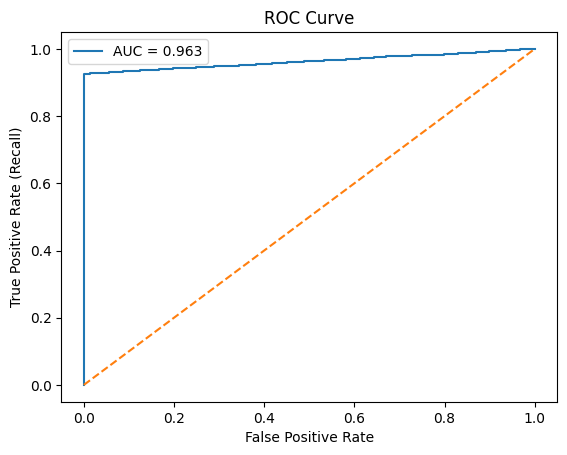

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability for positive class ("Active")
y_proba = base_pipe.predict_proba(X_test)[:, 0]

fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label="Active")
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()

plot_filename = "ROC-Curve.png"
plt.savefig(plot_filename)

from google.colab import files
files.download(plot_filename)

plt.show()

In [69]:
## RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier(
    random_state=42,
    bootstrap=True,
    oob_score=True
)

In [19]:
preprocessor_tree = ColumnTransformer([
("skew", skewed_pipe, skewed_col),
("cat", cat_pipe, categorical_col),
])

In [ ]:
pipeline_rfc = ImbPipeline([
("signup_date", date_transformer),
("somte_nc", smote_nc),
("preprocessing", preprocessor),
("rfc", rfc)
])

In [ ]:
params_random = {
    "rfc__n_estimators": [200, 400, 600],
    "rfc__max_depth": [None, 10, 20, 30],
    "rfc__min_samples_split": [2, 5, 10],
    "rfc__min_samples_leaf": [1, 2, 4]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline_rfc,
    param_distributions=params_random,
    n_iter=30,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

In [ ]:
random_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('signup_date',
                                              FunctionTransformer(func=<function signup_date at 0x7e0b2acf0ea0>)),
                                             ('somte_nc',
                                              SMOTENC(categorical_features=['country',
                                                                            'subscription_type',
                                                                            'ad_interaction',
                                                                            'primary_device',
                                                                            'ad_conversion_to_subscription',
                                                                            'favorite_genre',
                                                                            'most_liked_feature',
                                                                            'desired_future_feature'],
                                                      random_state=42)),...
                                                                                'avg_listening_hours_per_week',
                                                                                'account_age_days',
                                                                                'signup_month',
                                                                                'signup_year'])])),
                                             ('rfc',
                                              RandomForestClassifier(oob_score=True,
                                                                     random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'rfc__max_depth': [None, 10, 20, 30],
                                        'rfc__min_samples_leaf': [1, 2, 4],
                                        'rfc__min_samples_split': [2, 5, 10],
                                        'rfc__n_estimators': [200, 400, 600]},
                   random_state=42, scoring='f1')

In [ ]:
random_search.best_params_

{'rfc__n_estimators': 600,
 'rfc__min_samples_split': 5,
 'rfc__min_samples_leaf': 4,
 'rfc__max_depth': 20}

In [ ]:
best_rfc = random_search.best_estimator_

In [ ]:
y_pred = best_rfc.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label='Active')}")
print(f"Recall : {recall_score(y_test, y_pred, pos_label='Active')}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='Active')}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(f"confusion matrix :\n{cm}")

Accuracy: 0.9375
Precision : 1.0
Recall : 0.9257895986701496
F1 Score : 0.9614649485171712
Classification Report:
              precision    recall  f1-score   support

      Active       1.00      0.93      0.96      8422
    Inactive       0.72      1.00      0.83      1578

    accuracy                           0.94     10000
   macro avg       0.86      0.96      0.90     10000
weighted avg       0.96      0.94      0.94     10000

confusion matrix :
[[7797  625]
 [   0 1578]]


In [ ]:
df.shape

(50000, 17)

(50000, 17)

In [70]:
## GradientBoostingClassifier

In [37]:
from sklearn.ensemble import GradientBoostingClassifier
from scipy.stats import randint, uniform
param_dist_gb = {
    "gbc__n_estimators": randint(150, 400),

    "gbc__learning_rate": uniform(0.01, 0.08),  # smaller range

    "gbc__max_depth": randint(3, 6),  # avoid deep trees

    "gbc__min_samples_split": randint(5, 15),  # avoid very small splits

    "gbc__min_samples_leaf": randint(2, 6),  # avoid 1 (unstable)

    "gbc__subsample": uniform(0.7, 0.3),  # 0.7 to 1.0 (safer)

    "gbc__max_features": ["sqrt", "log2"]  # remove None (unstable)
}

In [38]:
gbc = GradientBoostingClassifier(random_state=42)

In [39]:
pipe_gbc = ImbPipeline([
    ("signup_date", date_transformer),
    ("smote_nc", smote_nc),
    ("preprocessing",preprocessor_tree),
    ("gbc",gbc)])

In [40]:
from sklearn.model_selection import RandomizedSearchCV

random_gb = RandomizedSearchCV(
    pipe_gbc,
    param_distributions=param_dist_gb,
    n_iter=50,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=2,
    error_score = 0
)

In [41]:
random_gb.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, error_score=0,
                   estimator=Pipeline(steps=[('signup_date',
                                              FunctionTransformer(func=<function signup_date at 0x785381779760>)),
                                             ('smote_nc',
                                              SMOTENC(categorical_features=['country',
                                                                            'subscription_type',
                                                                            'ad_interaction',
                                                                            'primary_device',
                                                                            'ad_conversion_to_subscription',
                                                                            'favorite_genre',
                                                                            'most_liked_feature',
                                                                            'desired_future_feature'],
                                                      rand...
                                        'gbc__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7853806fdd60>,
                                        'gbc__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7853806fdb50>,
                                        'gbc__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7853806fc500>,
                                        'gbc__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7853806fce30>},
                   random_state=42, scoring='f1', verbose=2)

In [44]:
random_gb.best_params_

{'gbc__learning_rate': np.float64(0.039963209507789),
 'gbc__max_depth': 3,
 'gbc__max_features': 'sqrt',
 'gbc__min_samples_leaf': 4,
 'gbc__min_samples_split': 12,
 'gbc__n_estimators': 338,
 'gbc__subsample': np.float64(0.879055047383946)}

In [45]:
random_gb.best_score_

np.float64(0.0)

In [46]:
final_gbc = GradientBoostingClassifier(
    n_estimators= 500,
    max_depth= 3,
    min_samples_split= 12,
    min_samples_leaf= 3,
    max_features="sqrt",
    random_state=42,
)

final_gbc_pipe = ImbPipeline([
    ("signup_date", date_transformer),
    ("smote_nc", smote_nc),
    ("preprocessing",preprocessor_tree),
    ("gbc",final_gbc)])

final_gbc_pipe.fit(X_train, y_train)

Pipeline(steps=[('signup_date',
                 FunctionTransformer(func=<function signup_date at 0x785381779760>)),
                ('smote_nc',
                 SMOTENC(categorical_features=['country', 'subscription_type',
                                               'ad_interaction',
                                               'primary_device',
                                               'ad_conversion_to_subscription',
                                               'favorite_genre',
                                               'most_liked_feature',
                                               'desired_future_feature'],
                         random_state=42)),
                ('preprocessing',
                 ColumnTransformer...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['country',
                                                   'subscription_type',
                                                   'ad_interaction',
                                                   'primary_device',
                                                   'ad_conversion_to_subscription',
                                                   'favorite_genre',
                                                   'most_liked_feature',
                                                   'desired_future_feature'])])),
                ('gbc',
                 GradientBoostingClassifier(max_features='sqrt',
                                            min_samples_leaf=3,
                                            min_samples_split=12,
                                            n_estimators=500,
                                            random_state=42))])

In [47]:
random_gb.cv_results_["mean_test_score"]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [59]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
le = LabelEncoder()

# Fit and transform y_train to convert string labels to numerical labels
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
# Print the bincount of the encoded y_train
print(np.bincount(y_train_encoded))

[33687  6313]


In [49]:
y_pred = final_gbc_pipe.predict(X_test)

In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label='Active')}")
print(f"Recall : {recall_score(y_test, y_pred, pos_label='Active')}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='Active')}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(f"confusion matrix :\n{cm}")

Accuracy: 0.9372
Precision : 0.9987202457128231
Recall : 0.9266207551650439
F1 Score : 0.9613205222961321
Classification Report:
              precision    recall  f1-score   support

      Active       1.00      0.93      0.96      8422
    Inactive       0.72      0.99      0.83      1578

    accuracy                           0.94     10000
   macro avg       0.86      0.96      0.90     10000
weighted avg       0.95      0.94      0.94     10000

confusion matrix :
[[7804  618]
 [  10 1568]]


In [68]:
best_gbc = random_gb.best_estimator_
y_pred = best_gbc.predict(X_test)
from sklearn.metrics import precision_score, recall_score, f1_score
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label='Active')}")
print(f"Recall : {recall_score(y_test, y_pred, pos_label='Active')}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='Active')}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(f"confusion matrix :\n{cm}")

Accuracy: 0.9374
Precision : 0.9994874423372629
Recall : 0.9261458085965328
F1 Score : 0.9614199433008751
Classification Report:
              precision    recall  f1-score   support

      Active       1.00      0.93      0.96      8422
    Inactive       0.72      1.00      0.83      1578

    accuracy                           0.94     10000
   macro avg       0.86      0.96      0.90     10000
weighted avg       0.95      0.94      0.94     10000

confusion matrix :
[[7800  622]
 [   4 1574]]


In [51]:
## XgBoosting

In [53]:
from xgboost import XGBClassifier

In [54]:
from scipy.stats import randint, uniform

param_dist_xgb = {
    "xgb__n_estimators": randint(200, 600),

    "xgb__learning_rate": uniform(0.01, 0.09),

    "xgb__max_depth": randint(3, 6),

    "xgb__subsample": uniform(0.75, 0.25),

    "xgb__colsample_bytree": uniform(0.7, 0.3),

    "xgb__gamma": uniform(0, 2),

    "xgb__min_child_weight": randint(2, 8),

    "xgb__reg_lambda": uniform(0.5, 1.5)
}

In [55]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

In [56]:
pipe_xgb = ImbPipeline([
    ("signup_date", date_transformer),
    ("smote_nc", smote_nc),
    ("preprocessing", preprocessor_tree),
    ("xgb", xgb)
])

In [57]:
random_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring="f1",
    n_jobs= 1,
    random_state=42,
    verbose=2,
    error_score = 0
)

In [60]:
random_xgb.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:13:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END xgb__colsample_bytree=0.8123620356542087, xgb__gamma=1.9014286128198323, xgb__learning_rate=0.07587945476302645, xgb__max_depth=3, xgb__min_child_weight=6, xgb__n_estimators=302, xgb__reg_lambda=1.1687491292803867, xgb__subsample=0.7749937289545007; total time=   5.5s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:13:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END xgb__colsample_bytree=0.8123620356542087, xgb__gamma=1.9014286128198323, xgb__learning_rate=0.07587945476302645, xgb__max_depth=3, xgb__min_child_weight=6, xgb__n_estimators=302, xgb__reg_lambda=1.1687491292803867, xgb__subsample=0.7749937289545007; total time=  10.2s


...

[CV] END xgb__colsample_bytree=0.7782680870025142, xgb__gamma=0.0306090805807695, xgb__learning_rate=0.09400926772715346, xgb__max_depth=3, xgb__min_child_weight=6, xgb__n_estimators=203, xgb__reg_lambda=1.4237767465848707, xgb__subsample=0.9859729011401893; total time=   4.8s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:38:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END xgb__colsample_bytree=0.7782680870025142, xgb__gamma=0.0306090805807695, xgb__learning_rate=0.09400926772715346, xgb__max_depth=3, xgb__min_child_weight=6, xgb__n_estimators=203, xgb__reg_lambda=1.4237767465848707, xgb__subsample=0.9859729011401893; total time=   5.6s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:38:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5, error_score=0,
                   estimator=Pipeline(steps=[('signup_date',
                                              FunctionTransformer(func=<function signup_date at 0x785381779760>)),
                                             ('smote_nc',
                                              SMOTENC(categorical_features=['country',
                                                                            'subscription_type',
                                                                            'ad_interaction',
                                                                            'primary_device',
                                                                            'ad_conversion_to_subscription',
                                                                            'favorite_genre',
                                                                            'most_liked_feature',
                                                                            'desired_future_feature'],
                                                      rand...
                                        'xgb__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78537f570a10>,
                                        'xgb__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78537f570470>,
                                        'xgb__reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78537f570aa0>,
                                        'xgb__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78537f570620>},
                   random_state=42, scoring='f1', verbose=2)

In [61]:
le.classes_

array(['Active', 'Inactive'], dtype=object)

In [63]:
random_xgb.best_params_

{'xgb__colsample_bytree': np.float64(0.8829989973347863),
 'xgb__gamma': np.float64(1.6663898234723287),
 'xgb__learning_rate': np.float64(0.025602818815699487),
 'xgb__max_depth': 3,
 'xgb__min_child_weight': 5,
 'xgb__n_estimators': 249,
 'xgb__reg_lambda': np.float64(1.4937834265309728),
 'xgb__subsample': np.float64(0.8279277690223528)}

In [64]:
final_xgb = random_xgb.best_estimator_

In [65]:
y_pred = final_xgb.predict(X_test)

In [67]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred)}")
print(f"Precision : {precision_score(y_test_encoded, y_pred, pos_label=le.transform(['Active'])[0])}")
print(f"Recall : {recall_score(y_test_encoded, y_pred, pos_label=le.transform(['Active'])[0])}")
print(f"F1 Score : {f1_score(y_test_encoded, y_pred, pos_label=le.transform(['Active'])[0])}")
print(f"Classification Report:\n{classification_report(y_test_encoded, y_pred, target_names=le.classes_)}")
cm = confusion_matrix(y_test_encoded, y_pred)
print(f"confusion matrix :\n{cm}")

Accuracy: 0.9376
Precision : 1.0
Recall : 0.9259083353122773
F1 Score : 0.9615289765721332
Classification Report:
              precision    recall  f1-score   support

      Active       1.00      0.93      0.96      8422
    Inactive       0.72      1.00      0.83      1578

    accuracy                           0.94     10000
   macro avg       0.86      0.96      0.90     10000
weighted avg       0.96      0.94      0.94     10000

confusion matrix :
[[7798  624]
 [   0 1578]]


In [26]:
## Best Model (logistic regressor without smote_nc and with parameter tuning)

In [28]:
import joblib

joblib.dump(grid, "model.pkl")

['model.pkl']

In [29]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
joblib.dump(grid, "/content/drive/MyDrive/model.pkl")

['/content/drive/MyDrive/model.pkl']

In [33]:
files.download("/content/drive/MyDrive/model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
"""
to load the model:-

import joblib
model = joblib.load("/content/drive/MyDrive/model.pkl")

"""